In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
from matplotlib.lines import Line2D
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder

# Подготовка набора данных

In [30]:
(penguins := pd.read_csv("penguins.csv"))

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female
...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male


In [31]:
penguins = penguins[penguins.bill_length_mm.notna()]
penguins[penguins.isna().any(axis=1)]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
178,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
218,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
256,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
268,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


In [32]:
penguins = penguins.fillna("unknown")
penguins_adelie = penguins[penguins.species == "Adelie"]
penguins_gentoo = penguins[penguins.species == "Gentoo"]
penguins_chinstrap = penguins[penguins.species == "Chinstrap"]
label_male, label_female, label_unknown = "Самцы", "Самки", "Неизвестно"
hue_male, hue_female, hue_unknown = "male", "female", "unknown"
color_male, color_female, color_unknown = "#4c72b0", "#dd8452", "#55a868"
palette_sex = {hue_male: color_male, hue_female: color_female, hue_unknown: color_unknown}
marker_male = Line2D([], [], color=color_male, linestyle="None", marker=".", markersize=8)
marker_female = Line2D([], [], color=color_female, linestyle="None", marker=".", markersize=8)
marker_unknown = Line2D([], [], color=color_unknown, linestyle="None", marker=".", markersize=16)

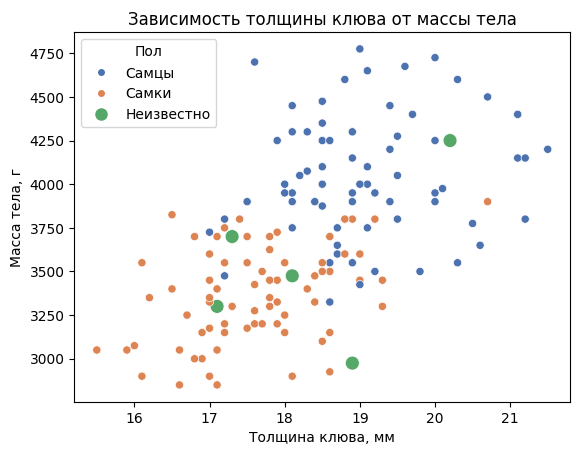

In [33]:
sns.scatterplot(
    penguins_adelie, x=penguins_adelie.bill_depth_mm, y=penguins_adelie.body_mass_g,
    hue="sex", size="sex",
    palette=palette_sex, hue_order=[hue_male, hue_female, hue_unknown], sizes=[35, 35, 100]
).set(
    title="Зависимость толщины клюва от массы тела", xlabel="Толщина клюва, мм", ylabel="Масса тела, г"
)
plt.legend(
    handles=[marker_male, marker_female, marker_unknown],
    labels=[label_male, label_female, label_unknown],
    title="Пол"
);

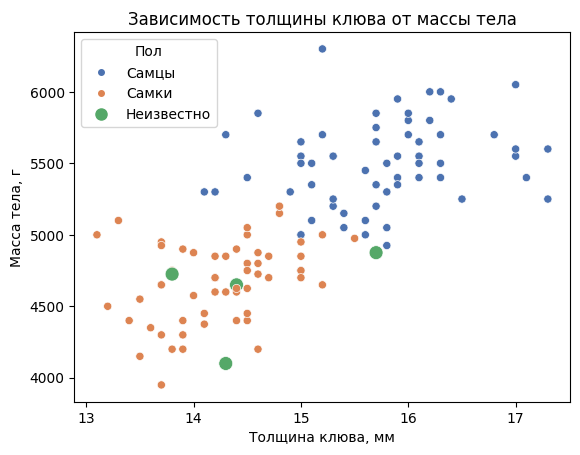

In [34]:
sns.scatterplot(
    penguins_gentoo, x=penguins_gentoo.bill_depth_mm, y=penguins_gentoo.body_mass_g,
    hue="sex", size="sex", palette=palette_sex,
    hue_order=[hue_male, hue_female, hue_unknown], sizes=[35, 35, 100]
).set(
    title="Зависимость толщины клюва от массы тела", xlabel="Толщина клюва, мм", ylabel="Масса тела, г"
)
plt.legend(
    handles=[marker_male, marker_female, marker_unknown],
    labels=[label_male, label_female, label_unknown],
    title="Пол"
);

In [35]:
penguins_adelie[penguins_adelie.sex == "unknown"]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,unknown
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,unknown
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,unknown
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,unknown
47,Adelie,Dream,37.5,18.9,179.0,2975.0,unknown


In [36]:
penguins_gentoo[penguins_gentoo.sex == "unknown"]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
178,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,unknown
218,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,unknown
256,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,unknown
268,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,unknown


In [37]:
penguins_adelie.at[8, "sex"] = "female"
penguins_adelie.at[9, "sex"] = "male"
penguins_adelie.at[10, "sex"] = "female"
penguins_adelie.at[11, "sex"] = "female"
penguins_adelie.at[47, "sex"] = "female"
penguins_gentoo.at[178, "sex"] = "female"
penguins_gentoo.at[218, "sex"] = "female"
penguins_gentoo.at[256, "sex"] = "female"
penguins_gentoo.at[268, "sex"] = "male"

In [38]:
(penguins := pd.concat([penguins_adelie, penguins_gentoo, penguins_chinstrap]))

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male
...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male


In [39]:
one_hot_encoder = OneHotEncoder()
encoded_species = one_hot_encoder.fit_transform(penguins[["species"]])
penguins[["adelie", "chinstrap", "gentoo"]] = encoded_species.toarray()
encoded_island = one_hot_encoder.fit_transform(penguins[["island"]])
penguins[["biscoe", "dream", "torgersen"]] = encoded_island.toarray()
penguins.drop(columns=["species", "island"], inplace=True)
penguins

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,adelie,chinstrap,gentoo,biscoe,dream,torgersen
0,39.1,18.7,181.0,3750.0,male,1.0,0.0,0.0,0.0,0.0,1.0
1,39.5,17.4,186.0,3800.0,female,1.0,0.0,0.0,0.0,0.0,1.0
2,40.3,18.0,195.0,3250.0,female,1.0,0.0,0.0,0.0,0.0,1.0
4,36.7,19.3,193.0,3450.0,female,1.0,0.0,0.0,0.0,0.0,1.0
5,39.3,20.6,190.0,3650.0,male,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
339,55.8,19.8,207.0,4000.0,male,0.0,1.0,0.0,0.0,1.0,0.0
340,43.5,18.1,202.0,3400.0,female,0.0,1.0,0.0,0.0,1.0,0.0
341,49.6,18.2,193.0,3775.0,male,0.0,1.0,0.0,0.0,1.0,0.0
342,50.8,19.0,210.0,4100.0,male,0.0,1.0,0.0,0.0,1.0,0.0


In [40]:
penguins.sex = penguins.sex.map({"female": 0, "male": 1})
penguins

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,adelie,chinstrap,gentoo,biscoe,dream,torgersen
0,39.1,18.7,181.0,3750.0,1,1.0,0.0,0.0,0.0,0.0,1.0
1,39.5,17.4,186.0,3800.0,0,1.0,0.0,0.0,0.0,0.0,1.0
2,40.3,18.0,195.0,3250.0,0,1.0,0.0,0.0,0.0,0.0,1.0
4,36.7,19.3,193.0,3450.0,0,1.0,0.0,0.0,0.0,0.0,1.0
5,39.3,20.6,190.0,3650.0,1,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
339,55.8,19.8,207.0,4000.0,1,0.0,1.0,0.0,0.0,1.0,0.0
340,43.5,18.1,202.0,3400.0,0,0.0,1.0,0.0,0.0,1.0,0.0
341,49.6,18.2,193.0,3775.0,1,0.0,1.0,0.0,0.0,1.0,0.0
342,50.8,19.0,210.0,4100.0,1,0.0,1.0,0.0,0.0,1.0,0.0


In [41]:
(y := penguins.sex)

0      1
1      0
2      0
4      0
5      1
      ..
339    1
340    0
341    1
342    1
343    0
Name: sex, Length: 342, dtype: int64

In [42]:
(X := penguins.drop(columns="sex"))

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,adelie,chinstrap,gentoo,biscoe,dream,torgersen
0,39.1,18.7,181.0,3750.0,1.0,0.0,0.0,0.0,0.0,1.0
1,39.5,17.4,186.0,3800.0,1.0,0.0,0.0,0.0,0.0,1.0
2,40.3,18.0,195.0,3250.0,1.0,0.0,0.0,0.0,0.0,1.0
4,36.7,19.3,193.0,3450.0,1.0,0.0,0.0,0.0,0.0,1.0
5,39.3,20.6,190.0,3650.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
339,55.8,19.8,207.0,4000.0,0.0,1.0,0.0,0.0,1.0,0.0
340,43.5,18.1,202.0,3400.0,0.0,1.0,0.0,0.0,1.0,0.0
341,49.6,18.2,193.0,3775.0,0.0,1.0,0.0,0.0,1.0,0.0
342,50.8,19.0,210.0,4100.0,0.0,1.0,0.0,0.0,1.0,0.0


In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [44]:
min_max_scaler = MinMaxScaler()
X_train_norm = min_max_scaler.fit_transform(X_train)
X_test_norm = min_max_scaler.transform(X_test)

# Своя реализация KNN

In [45]:
class MyKNNClassifier:
    def __init__(self, n_neighbors=5, weights="uniform", p=2, metric="minkowski"):
        self.n_neighbors = n_neighbors
        self.weights = weights
        self.p = p
        self.metric = metric

        self.X_train = None
        self.y_train = None

        if self.n_neighbors <= 0:
            raise ValueError("Ошибка: n_neighbors должен быть положительным числом")
        if self.weights not in ["uniform", "distance"]:
            raise ValueError("Ошибка: недопустимое значение weights")
        if self.p <= 0:
            raise ValueError("Ошибка: p должен быть положительным числом")
        if self.metric not in ["minkowski", "euclidean", "manhattan", "cosine"]:
            raise ValueError(f"Ошибка: недопустимое значение metric")
    
    def __calculate_distance(self, x1, x2):
        if self.metric == "minkowski":
            return np.power(np.sum(np.power(np.abs(x1 - x2), self.p), axis=1), 1 / self.p)
        if self.metric == "euclidean":
            return np.sqrt(np.sum((x1 - x2) ** 2, axis=1))
        if self.metric == "manhattan":
            return np.sum(np.abs(x1 - x2), axis=1)
        if self.metric == "cosine":
            norm1 = np.linalg.norm(x1)
            norm2 = np.linalg.norm(x2, axis=1)
            return 1 - np.dot(x1, x2.T) / (norm1 * norm2 + 1e-10)
    
    def fit(self, X, y):
        self.X_train = np.array(X, dtype=float)
        self.y_train = np.array(y)
        
        if len(self.X_train) != len(self.y_train):
            raise ValueError("Ошибка: X и y должны иметь одинаковую длину")
        if len(self.X_train) < self.n_neighbors:
            raise ValueError(f"Ошибка: n_neighbors не может быть больше длины X")
        
        return self
    
    def predict(self, X):
        if self.X_train is None or self.y_train is None:
            raise ValueError("Ошибка: перед предсказанием нужно обучить модель")
        
        X_test = np.array(X, dtype=float)

        if self.X_train.shape[1] != X_test.shape[1]:
            raise ValueError(f"Ошибка: ожидается {self.X_train.shape[1]} признаков, а получено {X_test.shape[1]}")
        
        preds = []
        for x in X_test:
            distances = self.__calculate_distance(x, self.X_train)
            nearest_indices = np.argsort(distances)[:self.n_neighbors]
            nearest_labels = self.y_train[nearest_indices]
            nearest_distances = distances[nearest_indices]
            
            if self.weights == "uniform":
                pred = max(Counter(nearest_labels).items(), key=lambda x: x[1])[0]
            else:
                weights = 1 / (nearest_distances + 1e-10)
                weights_dict = {}
                for label, weight in zip(nearest_labels, weights):
                    weights_dict[label] = weights_dict.get(label, 0) + weight
                pred = max(weights_dict.items(), key=lambda x: x[1])[0]
            
            preds.append(pred)
        
        return np.array(preds)
    
    def predict_proba(self, X):
        if self.X_train is None or self.y_train is None:
            raise ValueError("Ошибка: перед предсказанием нужно обучить модель")
        
        X_test = np.array(X, dtype=float)
        labels = np.unique(self.y_train)
        proba = np.zeros((len(X_test), len(labels)))
        
        for i, x in enumerate(X_test):
            distances = self.__calculate_distance(x, self.X_train)
            nearest_indices = np.argsort(distances)[:self.n_neighbors]
            nearest_labels = self.y_train[nearest_indices]
            nearest_distances = distances[nearest_indices]
            
            if self.weights == "uniform":
                for j, label in enumerate(labels):
                    proba[i, j] = np.sum(nearest_labels == label) / self.n_neighbors
            else:
                weights = 1 / (nearest_distances + 1e-10)
                for j, label in enumerate(labels):
                    mask = nearest_labels == label
                    proba[i, j] = np.sum(weights[mask]) / np.sum(weights)
        
        return proba
    
    def score(self, X, y):
        y_pred = self.predict(X)
        y_true = np.array(y)
        return np.mean(y_pred == y_true).item()

# Сравнение библиотечной реализации со своей

In [46]:
knn1 = KNeighborsClassifier(n_neighbors=7, weights="distance", p=2, metric="minkowski")
knn1.fit(X_train_norm, y_train)
knn1.score(X_test_norm, y_test)

0.9514563106796117

In [47]:
knn2 = MyKNNClassifier(n_neighbors=7, weights="distance", p=2, metric="minkowski")
knn2.fit(X_train_norm, y_train)
knn2.score(X_test_norm, y_test)

0.9514563106796117

In [48]:
knn1.predict_proba(X_test_norm[:10])

array([[0.        , 1.        ],
       [1.        , 0.        ],
       [0.        , 1.        ],
       [1.        , 0.        ],
       [0.        , 1.        ],
       [0.09885819, 0.90114181],
       [0.49212738, 0.50787262],
       [0.60487269, 0.39512731],
       [0.        , 1.        ],
       [0.71788965, 0.28211035]])

In [49]:
knn2.predict_proba(X_test_norm[:10])

array([[0.        , 1.        ],
       [1.        , 0.        ],
       [0.        , 1.        ],
       [1.        , 0.        ],
       [0.        , 1.        ],
       [0.09885819, 0.90114181],
       [0.49212738, 0.50787262],
       [0.60487269, 0.39512731],
       [0.        , 1.        ],
       [0.71788965, 0.28211035]])

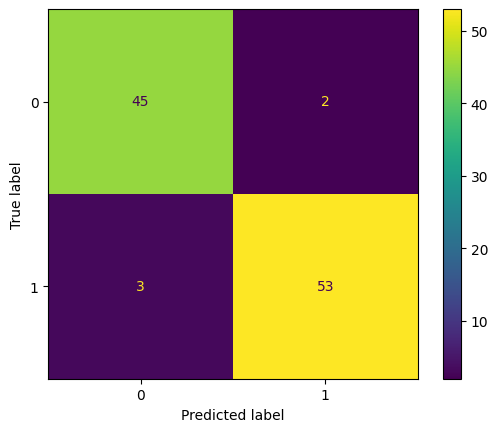

In [50]:
y_knn1 = knn1.predict(X_test_norm)
ConfusionMatrixDisplay.from_predictions(y_test, y_knn1);

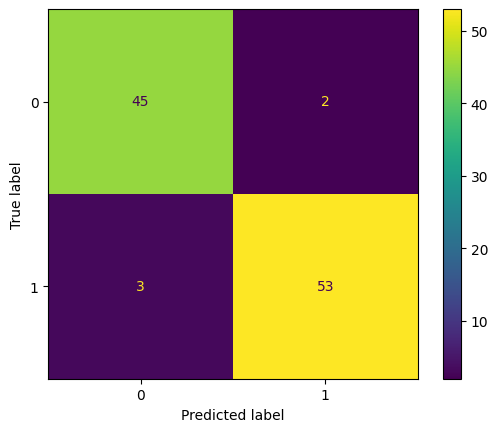

In [51]:
y_knn2 = knn2.predict(X_test_norm)
ConfusionMatrixDisplay.from_predictions(y_test, y_knn2);

In [60]:
pd.concat([X_test[y_test != y_knn1], y_test[y_test != y_knn1]], axis=1).sort_index().sort_index()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,adelie,chinstrap,gentoo,biscoe,dream,torgersen,sex
114,39.6,20.7,191.0,3900.0,1.0,0.0,0.0,1.0,0.0,0.0,0
141,40.6,17.2,187.0,3475.0,1.0,0.0,0.0,0.0,1.0,0.0,1
177,46.1,15.1,215.0,5100.0,0.0,0.0,1.0,1.0,0.0,0.0,1
297,48.5,17.5,191.0,3400.0,0.0,1.0,0.0,0.0,1.0,0.0,1
343,50.2,18.7,198.0,3775.0,0.0,1.0,0.0,0.0,1.0,0.0,0


In [61]:
pd.concat([X_test[y_test != y_knn2], y_test[y_test != y_knn2]], axis=1).sort_index()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,adelie,chinstrap,gentoo,biscoe,dream,torgersen,sex
114,39.6,20.7,191.0,3900.0,1.0,0.0,0.0,1.0,0.0,0.0,0
141,40.6,17.2,187.0,3475.0,1.0,0.0,0.0,0.0,1.0,0.0,1
177,46.1,15.1,215.0,5100.0,0.0,0.0,1.0,1.0,0.0,0.0,1
297,48.5,17.5,191.0,3400.0,0.0,1.0,0.0,0.0,1.0,0.0,1
343,50.2,18.7,198.0,3775.0,0.0,1.0,0.0,0.0,1.0,0.0,0
